# Multi-Model Engagement Analysis: Real-Data Verification
This notebook analyzes the results of the live camera test, comparing the ensemble "actual" score against individual exported models and the 60-second predictive forecast.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'sans-serif'

## 📂 Data Preparation
Loading the multi-model results from `engagement_test_results.csv`.

In [2]:
try:
    df = pd.read_csv('engagement_test_results.csv')
    model_cols = [c for c in df.columns if c.startswith('score_')]
    print(f"Loaded {len(df)} samples. Available models: {model_cols}")
    display(df.head())
except FileNotFoundError:
    print("Error: CSV not found. Please run run_engagement_test.py first.")

Loaded 145 samples. Available models: ['score_baseline', 'score_bilstm', 'score_fusion', 'score_transformer']


,timestamp,elapsed_sec,actual_ensemble,face_detected,score_baseline,score_bilstm,score_fusion,score_transformer,forecast_60s,actual_at_forecast,forecast_error
0,16:25:29,2.17,69.9,True,33.15,45.25,31.98,39.92,71.4,NaN,NaN
1,16:25:31,8.11,69.9,True,33.15,45.25,26.18,37.00,71.6,NaN,NaN
2,16:25:33,9.91,48.7,True,33.15,45.25,30.87,34.00,50.3,NaN,NaN
3,16:25:34,11.40,38.1,True,33.15,45.25,36.31,30.01,39.8,NaN,NaN
4,16:25:36,12.91,35.9,True,33.15,45.25,36.81,32.18,37.6,NaN,NaN


## 📈 Multi-Model Timeline
Comparing how different architectures (Baseline vs. BiLSTM vs. Transformer) react to the SAME live camera features.

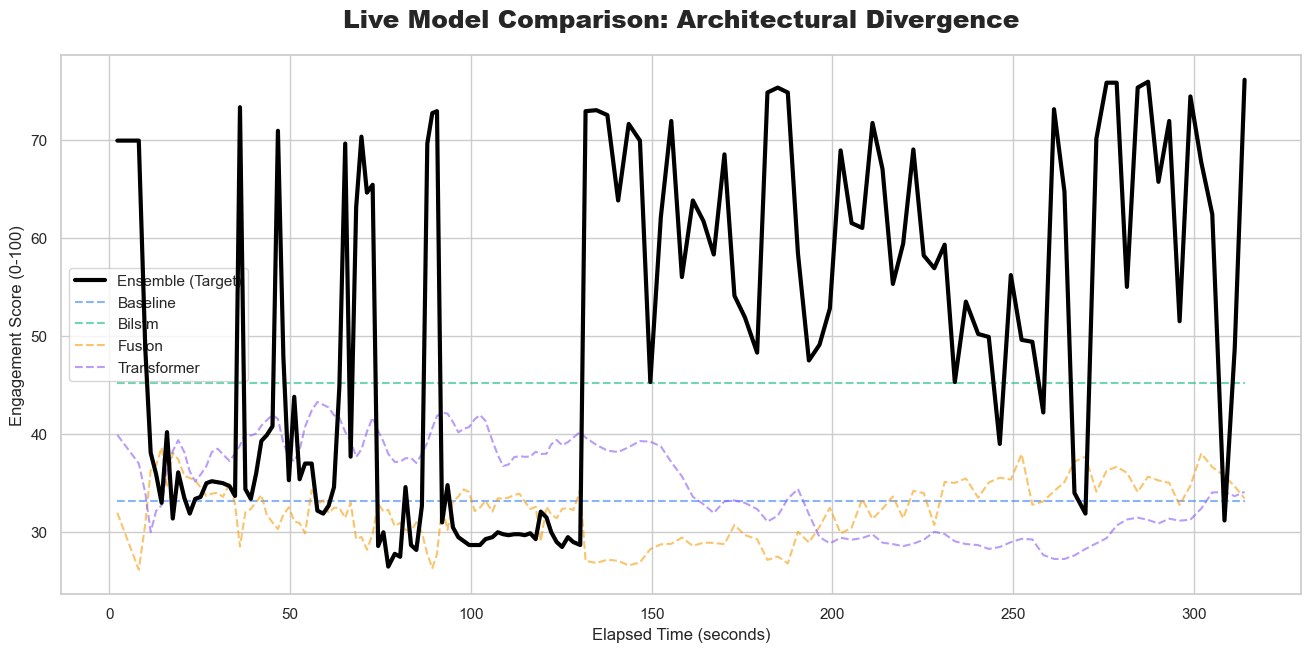

In [3]:
plt.figure(figsize=(16, 7))
plt.plot(df['elapsed_sec'], df['actual_ensemble'], label='Ensemble (Target)', color='black', linewidth=3, zorder=10)

colors = ['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']
for i, col in enumerate(model_cols):
    name = col.replace('score_', '').capitalize()
    plt.plot(df['elapsed_sec'], df[col], label=name, color=colors[i % len(colors)], alpha=0.6, linestyle='--')

plt.title('Live Model Comparison: Architectural Divergence', fontsize=18, fontweight='black', pad=20)
plt.xlabel('Elapsed Time (seconds)', fontsize=12)
plt.ylabel('Engagement Score (0-100)', fontsize=12)
plt.legend()
plt.show()

## 🎯 Forecasting Accuracy (60s Window)
Evaluated specifically against the ensemble ground truth.

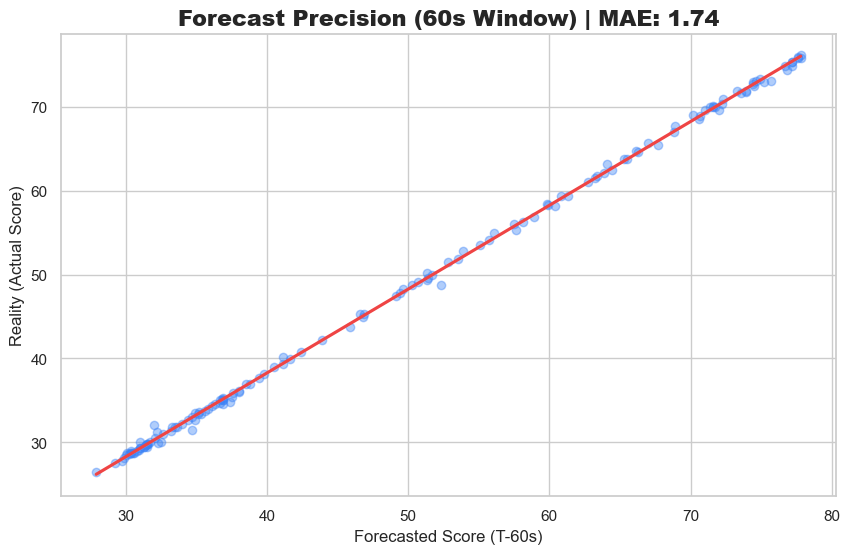

In [4]:
df_full = df.dropna(subset=['forecast_60s'])
if not df_full.empty:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='forecast_60s', y='actual_ensemble', data=df_full, 
                scatter_kws={'alpha':0.4, 'color':'#3b82f6'}, line_kws={'color':'#ef4444'})
    
    mae = mean_absolute_error(df_full['actual_ensemble'], df_full['forecast_60s'])
    plt.title(f'Forecast Precision (60s Window) | MAE: {round(mae, 2)}', fontsize=16, fontweight='black')
    plt.xlabel('Forecasted Score (T-60s)')
    plt.ylabel('Reality (Actual Score)')
    plt.show()
else:
    print("Wait for 60s of data to see the forecast comparison.")

## 🧬 Architectural Correlation
Heatmap showing which models track each other most closely.

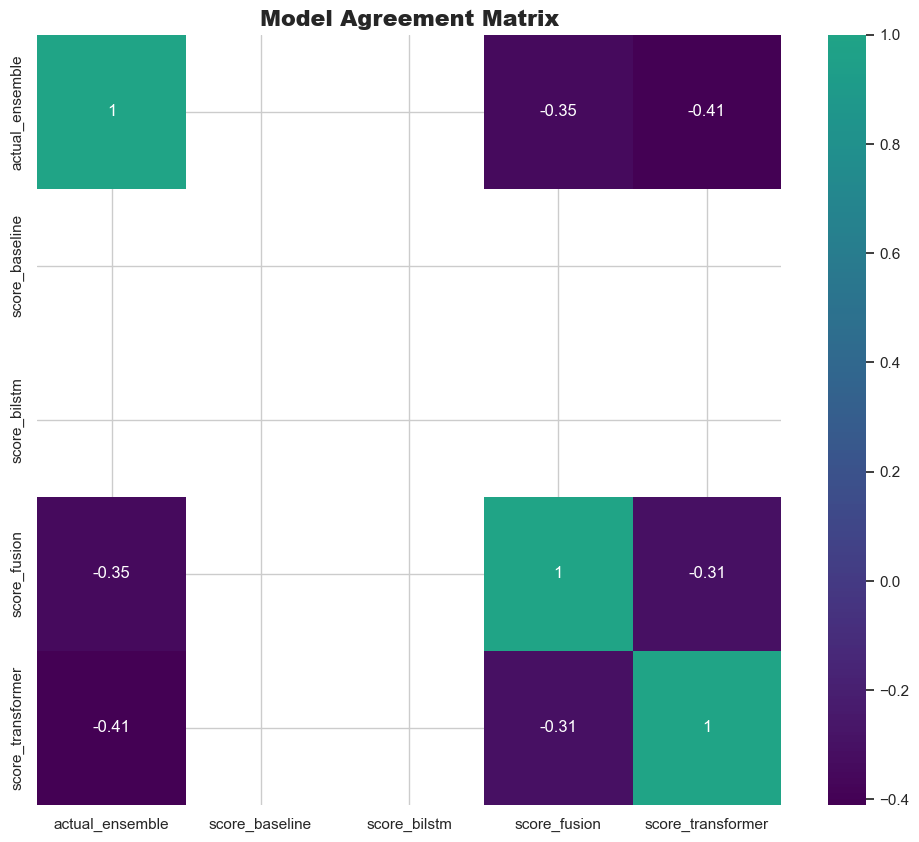

In [5]:
compare_cols = ['actual_ensemble'] + model_cols
corr = df[compare_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='viridis', center=0.8)
plt.title('Model Agreement Matrix', fontsize=16, fontweight='black')
plt.show()

## 📈 Granular XGBoost Dimensions
Looking at the individual components of the ensemble: Engagement, Boredom, Confusion, and Frustration.

In [6]:
xgb_cols = ['xgb_engagement', 'xgb_boredom', 'xgb_confusion', 'xgb_frustration']
if all(c in df.columns for c in xgb_cols):
    plt.figure(figsize=(16, 6))
    for col in xgb_cols:
        plt.plot(df['elapsed_sec'], df[col], label=col.replace('xgb_', '').capitalize())
    
    plt.title('XGBoost Internal Dimensions Timeline', fontsize=16, fontweight='black')
    plt.xlabel('Time (s)')
    plt.ylabel('Score (0-100)')
    plt.legend()
    plt.show()
else:
    print("Granular XGB columns missing in CSV.")

Granular XGB columns missing in CSV.


## 🚫 Behavioral Lapses: Face Detection
Visualizing periods where the face was not detected by MediaPipe.

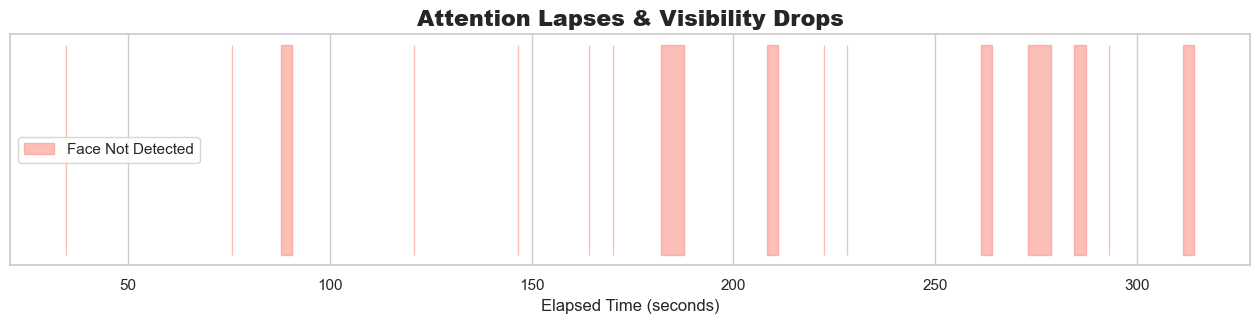

Total visibility lapse: 17.93% of the session.


In [7]:
plt.figure(figsize=(16, 3))
plt.fill_between(df['elapsed_sec'], 0, 1, where=~df['face_detected'], color='salmon', alpha=0.5, label='Face Not Detected')
plt.yticks([])
plt.title('Attention Lapses & Visibility Drops', fontsize=16, fontweight='black')
plt.xlabel('Elapsed Time (seconds)')
plt.legend()
plt.show()

lapse_pct = (1 - df['face_detected'].mean()) * 100
print(f"Total visibility lapse: {round(lapse_pct, 2)}% of the session.")